# Classification avec pytorch LSTM

- author : Sylvie Dagoret-Campagne
- affiliation : IJCLab/IN2P3/CNRS
- creation date : 2025-11-06

1️⃣ Modèles séquentiels / temporels (RNN, LSTM, GRU)

- Les courbes de lumière sont naturellement des séries temporelles. Au lieu de résumer tout en features, tu peux traiter la séquence complète par bande :
- Input : MJD, flux, flux_err par bande
- RNN / LSTM / GRU → apprend la dynamique des variations de flux dans le temps
- Output : type de SN ou probabilité multi-classes
- 💡 Avantages : capture les formes des courbes (rise, plateau, décroissance)
- 💡 Inconvénients : plus gourmand en données et GPU, nécessite padding ou masking si les séquences ont des longueurs différentes

In [1]:
import torch.nn as nn

class SN_LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        _, (hn, _) = self.lstm(x)  # hn: hidden state final
        out = self.fc(hn[-1])
        return out

- input_dim = 2 ou 3 (flux, flux_err, optionnellement bande encodée)
- hidden_dim : 32–128 suffisent pour commencer
- Prétraitement : séquences padding ou découpées à longueur fixe

2️⃣ Transformers / LLM pour séries temporelles
- Les transformers (ou petits LLMs) commencent à être utilisés pour les lightcurves :
- Input : séquence de tokens ou vecteurs (flux, MJD, bande)
- Attention apprend à se concentrer sur les points clés (pic, montée, décroissance)
- Output : classification multi-classes
- Avantages : meilleure capture des relations longues distances dans la série.
- Inconvénients : lourd, nécessite GPU, tuning complexe.
- Des implémentations existent sur Hugging Face :
- Modèles Time Series Transformer
- AstroNet et SuperNNova pour transients

3️⃣ Approche hybride
- Tu peux combiner features classiques + séquence complète :
- Extraire features globales (flux_max, flux_mean, rise_time)
- Coupler à une LSTM ou transformer pour capturer la dynamique
- Fusionner dans un réseau final (MLP) pour la classification

💡 Suggestion pour ton notebook NERSC :

- Commencer avec MLP sur features (déjà fait)
- Ensuite, préparer les séquences : MJD/flux par bande, padding, mask
- Tester LSTM/GRU sur un sous-échantillon pour vérifier performance et temps GPU
- Enfin, explorer Transformers si tu veux vraiment capturer les patterns complexes

## Prepare data

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from astropy.io import fits
import glob, os
import random
import fitsio

In [4]:
import sys
print(sys.executable)

/global/common/software/lsst/gitlab/td_env-dev/2024-03-08-06-23/conda/envs/lsst-scipipe-4.1.0-exact/bin/python


In [5]:
#!ls /global/cfs/cdirs/lsst/www/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2

In [6]:
# Répertoire d'un type de SN
BASE_DIR = "/global/cfs/cdirs/lsst/www/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2"
sn_type = "ELASTICC2_TRAIN_02_SNIa-SALT3"
sample_types = [
    "ELASTICC2_TRAIN_02_SNIa-SALT3",
    "ELASTICC2_TRAIN_02_SNIc-Templates",
    "ELASTICC2_TRAIN_02_SNIb-Templates"]


dict_sntype_to_files = {}

for sn_type in sample_types:
    PATH = os.path.join(BASE_DIR, sn_type)
    HEAD_PATH = os.path.join(PATH, "HEAD")
    PHOT_PATH = os.path.join(PATH, "PHOT")
    head_files = sorted(glob.glob(os.path.join(PATH, "*_HEAD.FITS.gz")))
    phot_files = sorted(glob.glob(os.path.join(PATH, "*_PHOT.FITS.gz")))
    dict_sntype_to_files[sn_type] = {"head_files" : head_files, "phot_files": phot_files }

In [7]:
list(dict_sntype_to_files.keys())[0]

'ELASTICC2_TRAIN_02_SNIa-SALT3'

In [8]:
def load_lightcurve(head_file, phot_file, lctype):
    import pandas as pd
    from astropy.io import fits

    head = fits.open(head_file)[1].data
    phot = fits.open(phot_file)[1].data

    # Récupère l’identifiant SNID depuis le HEAD uniquement
    snid = str(head["SNID"][0]).strip()

    # Création du DataFrame photométrique
    df = pd.DataFrame({
        "SNID": snid,
        "LCTYPE": lctype,
        "MJD": phot["MJD"],
        "BAND": [b.strip() for b in phot["BAND"]],
        "FLUXCAL": phot["FLUXCAL"],
        "FLUXCALERR": phot["FLUXCALERR"]
    })

    # Forcer le little-endian pour toutes les colonnes float ou int
    for col in ["MJD", "FLUXCAL", "FLUXCALERR"]:
        df[col] = df[col].astype(df[col].dtype.newbyteorder('<'))

    return df, head

In [9]:
# -----------------------------
# 3️⃣ Lire un HEAD aléatoire
# -----------------------------
# select the first type of SN
sntype = list(dict_sntype_to_files.keys())[0]

#then specify the path
PATH = os.path.join(BASE_DIR, sntype)
head_file = os.path.join(PATH, random.choice(head_files))
head_data = fitsio.FITS(head_file)[1].read()
print("Colonnes HEAD :", head_data.dtype.names)
print("Exemple HEAD :\n", head_data[:1])

Colonnes HEAD : ('SNID', 'IAUC', 'FAKE', 'RA', 'DEC', 'PIXSIZE', 'NXPIX', 'NYPIX', 'SNTYPE', 'NOBS', 'PTROBS_MIN', 'PTROBS_MAX', 'MWEBV', 'MWEBV_ERR', 'REDSHIFT_HELIO', 'REDSHIFT_HELIO_ERR', 'REDSHIFT_FINAL', 'REDSHIFT_FINAL_ERR', 'VPEC', 'VPEC_ERR', 'HOSTGAL_NMATCH', 'HOSTGAL_NMATCH2', 'HOSTGAL_OBJID', 'HOSTGAL_FLAG', 'HOSTGAL_PHOTOZ', 'HOSTGAL_PHOTOZ_ERR', 'HOSTGAL_SPECZ', 'HOSTGAL_SPECZ_ERR', 'HOSTGAL_RA', 'HOSTGAL_DEC', 'HOSTGAL_SNSEP', 'HOSTGAL_DDLR', 'HOSTGAL_CONFUSION', 'HOSTGAL_LOGMASS', 'HOSTGAL_LOGMASS_ERR', 'HOSTGAL_LOGSFR', 'HOSTGAL_LOGSFR_ERR', 'HOSTGAL_LOGsSFR', 'HOSTGAL_LOGsSFR_ERR', 'HOSTGAL_COLOR', 'HOSTGAL_COLOR_ERR', 'HOSTGAL_ELLIPTICITY', 'HOSTGAL_OBJID2', 'HOSTGAL_SQRADIUS', 'HOSTGAL_OBJID_UNIQUE', 'HOSTGAL_ZPHOT_Q000', 'HOSTGAL_ZPHOT_Q010', 'HOSTGAL_ZPHOT_Q020', 'HOSTGAL_ZPHOT_Q030', 'HOSTGAL_ZPHOT_Q040', 'HOSTGAL_ZPHOT_Q050', 'HOSTGAL_ZPHOT_Q060', 'HOSTGAL_ZPHOT_Q070', 'HOSTGAL_ZPHOT_Q080', 'HOSTGAL_ZPHOT_Q090', 'HOSTGAL_ZPHOT_Q100', 'HOSTGAL_MAG_u', 'HOSTGAL_MAG

### Load a number of SN samples

In [10]:
NF= 50
lightcurves = []
for sntype, filesdict in dict_sntype_to_files.items() :
    head_files = filesdict["head_files"]
    phot_files = filesdict["phot_files"]
    for h, p in zip(head_files[:NF], phot_files[:NF]):
        try:
            df, head = load_lightcurve(h, p, sntype)
            lightcurves.append((df, head))
        except Exception as e:
            print(f"Erreur avec {h}: {e}")

print(f"{len(lightcurves)} courbes chargées")

120 courbes chargées


In [11]:
lightcurves[0]

(            SNID                         LCTYPE         MJD BAND     FLUXCAL  \
 0       62642131  ELASTICC2_TRAIN_02_SNIa-SALT3  61127.4072    z  -20.374577   
 1       62642131  ELASTICC2_TRAIN_02_SNIa-SALT3  61133.4143    z  -58.375961   
 2       62642131  ELASTICC2_TRAIN_02_SNIa-SALT3  61146.4158    r    1.244686   
 3       62642131  ELASTICC2_TRAIN_02_SNIa-SALT3  61155.4270    z    2.876942   
 4       62642131  ELASTICC2_TRAIN_02_SNIa-SALT3  61160.4259    z  -18.983221   
 ...          ...                            ...         ...  ...         ...   
 628599  62642131  ELASTICC2_TRAIN_02_SNIa-SALT3  60808.9887    i  -14.879949   
 628600  62642131  ELASTICC2_TRAIN_02_SNIa-SALT3  60809.0137    z    4.904209   
 628601  62642131  ELASTICC2_TRAIN_02_SNIa-SALT3  60831.9569    i   -3.602438   
 628602  62642131  ELASTICC2_TRAIN_02_SNIa-SALT3  60831.9682    z  -21.550646   
 628603  62642131  ELASTICC2_TRAIN_02_SNIa-SALT3   -777.0000    - -777.000000   
 
         FLUXCALERR  
 0  

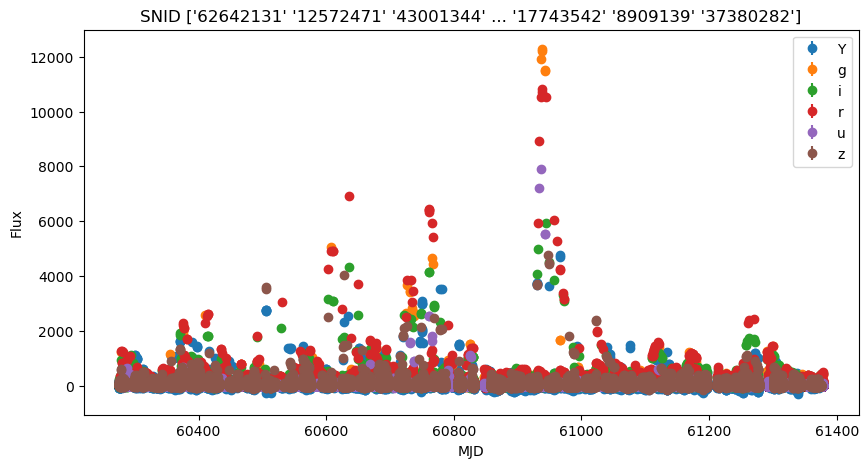

In [12]:
import matplotlib.pyplot as plt

def plot_lightcurve(df, title=None):
    plt.figure(figsize=(10, 5))
    bands = sorted(df['BAND'].unique())
    for band in bands:
        if band.strip() == '-':  # ignorer les bandes bidon
            continue
        d = df[df['BAND'] == band]
        plt.errorbar(d['MJD'], d['FLUXCAL'], yerr=d['FLUXCALERR'], fmt='o', label=band.strip())
    plt.xlabel("MJD")
    plt.ylabel("Flux")
    if title:
        plt.title(title)
    plt.legend()
    plt.show()
    
# Exemple pour la première courbe
plot_lightcurve(lightcurves[0][0], title="SNID " + str(lightcurves[0][1]['SNID']))

In [13]:
import numpy as np

def extract_features(df):
    bands = ['u', 'g', 'r', 'i', 'z', 'Y']
    features = []
    for band in bands:
        d = df[df['BAND'].str.strip() == band]
        if len(d) == 0:
            features.extend([np.nan, np.nan, np.nan, np.nan])
        else:
            flux = d['FLUXCAL'].values
            mjd = d['MJD'].values
            features.extend([
                np.max(flux),
                mjd[np.argmax(flux)],
                np.mean(flux),
                np.std(flux)
            ])
    return np.array(features)


In [14]:
lc = lightcurves[0]

In [15]:
lc[0]['LCTYPE'].unique()[0]

'ELASTICC2_TRAIN_02_SNIa-SALT3'

In [16]:
X = np.array([extract_features(lc[0]) for lc in lightcurves])
y = np.array([lc[0]['LCTYPE'].unique()[0] for lc in lightcurves])  # ou le label que tu as

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


                                   precision    recall  f1-score   support

    ELASTICC2_TRAIN_02_SNIa-SALT3       1.00      1.00      1.00         8
ELASTICC2_TRAIN_02_SNIb-Templates       0.75      1.00      0.86         6
ELASTICC2_TRAIN_02_SNIc-Templates       1.00      0.80      0.89        10

                         accuracy                           0.92        24
                        macro avg       0.92      0.93      0.92        24
                     weighted avg       0.94      0.92      0.92        24



## Classify with pytorch

- Super 😄 ! On va passer à une version PyTorch pour classifier les transients ELAsTiCC2 à partir des features extraites.
- L’idée :
- Dataset X et labels y (features comme flux_max, flux_mean, rise_time, etc.)
- Encodage des labels en indices (SNIa-SALT3 → 0, SNIc → 1, …)
- Mini réseau fully-connected (MLP)
- Entraînement et évaluation avec PyTorch

🔹 Ce que ce notebook PyTorch fait :
- Encode les labels en indices numériques (LabelEncoder).
- Utilise MLP simple avec 2 couches cachées.
- Optimiseur Adam, loss CrossEntropy.
- Mini-batch pour un entraînement efficace même sur NERSC CPU ou GPU.
- Affiche rapport de classification final avec précision par type de SN.

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ---------------------------
# 1️⃣ Préparer les données
# ---------------------------
X_values = X.astype(np.float32)
le = LabelEncoder()
y_values = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X_values, y_values, test_size=0.3, random_state=42, stratify=y_values
)

# Convertir en tensors
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# ---------------------------
# 2️⃣ Définir le modèle
# ---------------------------
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = num_classes

model = MLPClassifier(input_dim, hidden_dim, output_dim)

# ---------------------------
# 3️⃣ Définir loss + optimizer
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ---------------------------
# 4️⃣ Entraînement
# ---------------------------
epochs = 50
batch_size = 32

for epoch in range(epochs):
    permutation = torch.randperm(X_train_t.size()[0])
    epoch_loss = 0
    
    for i in range(0, X_train_t.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_t[indices], y_train_t[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

# ---------------------------
# 5️⃣ Évaluation
# ---------------------------
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    y_pred = torch.argmax(logits, dim=1).numpy()

print("Classification report :\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Epoch 1/50, Loss: 3361.1903
Epoch 10/50, Loss: 102.0157
Epoch 20/50, Loss: 142.0573
Epoch 30/50, Loss: 144.6177
Epoch 40/50, Loss: 53.2247
Epoch 50/50, Loss: 47.3649
Classification report :

                                   precision    recall  f1-score   support

    ELASTICC2_TRAIN_02_SNIa-SALT3       1.00      0.92      0.96        12
ELASTICC2_TRAIN_02_SNIb-Templates       0.00      0.00      0.00        12
ELASTICC2_TRAIN_02_SNIc-Templates       0.43      0.75      0.55        12

                         accuracy                           0.56        36
                        macro avg       0.48      0.56      0.50        36
                     weighted avg       0.48      0.56      0.50        36



## GEMINI LSTM

Absolument ! Voici un exemple d'implémentation d'un modèle LSTM pour la classification de courbes de lumière sous PyTorch.Ce modèle est structuré pour gérer les séries temporelles, où l'entrée est une séquence de caractéristiques ($t_i, m_i, \sigma_i$, etc.) pour chaque observation.

#### 1. 🏗️ Définition de la Classe du Modèle (LSTM)
Nous allons définir une classe LightCurveClassifier qui encapsule l'architecture LSTM.

In [ ]:
import torch
import torch.nn as nn

class LightCurveClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout_rate=0.5):
        """
        Initialise le modèle RNN (LSTM).

        Args:
            input_size (int): Nombre de caractéristiques par observation (ex: flux, erreur, bande encodée).
            hidden_size (int): Nombre d'unités dans la couche cachée du LSTM.
            num_layers (int): Nombre de couches LSTM empilées.
            num_classes (int): Nombre de classes de classification.
            dropout_rate (float): Taux de dropout après la couche LSTM.
        """
        super(LightCurveClassifier, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 🌙 Définition de la couche LSTM
        # batch_first=True signifie que l'entrée est (batch_size, seq_len, input_size)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)
        
        # 🌌 Couche de classification finale
        self.fc = nn.Linear(hidden_size, num_classes)
        
        # 💡 Dropout supplémentaire pour la couche dense
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        # x shape attendue : (batch_size, seq_len, input_size)
        
        # Initialisation de l'état caché (h0) et de l'état de la cellule (c0)
        # Ils doivent être de forme (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Passage dans la couche LSTM
        # out: sortie de tous les pas de temps (batch_size, seq_len, hidden_size)
        # (hn, cn): état caché et état de cellule du dernier pas de temps
        out, (hn, cn) = self.lstm(x, (h0, c0))
        
        # Utiliser uniquement la sortie du dernier pas de temps pour la classification
        # hn[-1, :, :] correspond à l'état caché de la dernière couche LSTM.
        # Vous pouvez aussi utiliser out[:, -1, :] si vous n'avez pas de padding.
        # Nous utilisons hn[-1] qui représente le dernier état caché de la dernière couche.
        last_hidden_state = hn[-1] 
        
        # 🚀 Classification
        out = self.dropout(last_hidden_state)
        out = self.fc(out)
        
        return out

#### 2. ⚙️ Préparation des Données (Simulée)
La gestion de l'échantillonnage irrégulier et du padding est essentielle en PyTorch.

`collate_fn` avec Padding : Pour regrouper des séquences de différentes longueurs dans un batch, vous devez utiliser nn.utils.rnn.pad_sequence dans votre DataLoader (via un collate_fn) pour ajouter du padding à la fin des séquences plus courtes.

`pack_padded_sequence` : Dans la méthode forward, vous devez idéalement utiliser nn.utils.rnn.pack_padded_sequence avant la couche LSTM et nn.utils.rnn.pad_packed_sequence après, afin que le LSTM ne traite pas les valeurs de padding comme de vraies observations.

Voici un exemple simple sans packing et unpacking pour illustrer le format de données :

In [19]:
# --- Configuration des Hyperparamètres ---
INPUT_SIZE = 5  # Ex: (flux, erreur, temps normalisé, u_band, g_band)
HIDDEN_SIZE = 128
NUM_LAYERS = 2
NUM_CLASSES = 10 
BATCH_SIZE = 32
MAX_SEQ_LEN = 100 # Longueur maximale après padding (si padding simple)

# --- Instanciation du Modèle ---
model = LightCurveClassifier(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Simulation d'un Batch de Données (Après Padding) ---
# x_batch : (batch_size, seq_len, input_size)
# Les séquences plus courtes ont été complétées (padding) par des zéros.
x_batch = torch.randn(BATCH_SIZE, MAX_SEQ_LEN, INPUT_SIZE) 
y_batch = torch.randint(0, NUM_CLASSES, (BATCH_SIZE,)) # Labels

# --- Étape d'Entraînement ---
model.train()
outputs = model(x_batch)
loss = criterion(outputs, y_batch)

# Rétropropagation
optimizer.zero_grad()
loss.backward()
optimizer.step()

#### 3. 🎯 Gestion des Séquences de Longueur Variable (Avancé)
Pour la classification de courbes de lumière, l'utilisation du pack_padded_sequence est fortement recommandée pour que le LSTM ignore correctement les observations de padding.

In [20]:
# Exemple de fonction de forward avec gestion du padding :

def forward_with_padding(self, x, lengths):
    # lengths : Tensor contenant la longueur réelle de chaque séquence dans le batch
    
    # 1. Empaqueter les séquences pour ignorer le padding
    x_packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
    
    # 2. Passage dans le LSTM
    out_packed, (hn, cn) = self.lstm(x_packed)
    
    # 3. Utiliser l'état caché final (hn)
    # hn a la forme (num_layers * num_directions, batch_size, hidden_size)
    last_hidden_state = hn[-1] # État de la dernière couche
    
    out = self.dropout(last_hidden_state)
    out = self.fc(out)
    
    return out



C'est excellent d'avoir un notebook de départ ! L'adaptation de ce code PyTorch nécessitera de se concentrer sur la gestion de la structure de vos données Rubin-LSST (multi-bande, irrégulières) et l'intégration des fonctionnalités de PyTorch pour la gestion des séquences.

En supposant que le notebook utilise une structure de base comme celle présentée précédemment, voici les étapes et les modifications clés pour l'adapter à vos données réelles, en mettant l'accent sur les sections Data Loading et le Preprocessing :

#### 1. 📂 Adapter la Classe Dataset PyTorch
La classe Dataset est l'endroit où vous allez charger, nettoyer et standardiser chaque courbe de lumière.

Modifications Clés :

    1. Chargement de la Courbe (Aperçu) : Vous devrez adapter la méthode __getitem__ pour charger une courbe de lumière spécifique de votre source de données (e.g., FITS, CSV, ou une base de données comme FastDB).

    2. Gestion Multi-Bande (Encodage) : Les courbes de lumière LSST ont 6 bandes (u,g,r,i,z,y). Vous devez les encoder pour qu'elles puissent être traitées par le réseau.

    3. Normalisation des Caractéristiques : Appliquer la normalisation des flux, des erreurs et du temps.

In [21]:
import torch
from torch.utils.data import Dataset
import numpy as np

class LsstLightCurveDataset(Dataset):
    def __init__(self, data_list, max_seq_len, normalizer, bands=['u', 'g', 'r', 'i', 'z', 'y']):
        # data_list : Liste des chemins/IDs vers vos courbes de lumière
        self.data_list = data_list
        self.max_seq_len = max_seq_len
        self.normalizer = normalizer # Utiliser un StandardScaler/MinMaxScaler
        self.band_map = {band: i for i, band in enumerate(bands)}
        self.num_bands = len(bands)

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        # 1. Charger les données (Simulé - remplacez par votre code de chargement réel)
        # Exemple de données chargées : df ou dict contenant 'time', 'flux', 'flux_err', 'band', 'label'
        lc_data, label = self._load_light_curve(self.data_list[idx]) 
        
        # 2. Préparation des Caractéristiques
        features = []
        
        # Le temps doit souvent être normalisé par le temps de début de l'observation
        time_norm = (lc_data['time'] - lc_data['time'].min()) / self.normalizer['time_scale']
        
        # Normalisation du flux et de l'erreur (utiliser des normalisateurs pré-calculés)
        flux_norm = self.normalizer['flux'].transform(lc_data['flux'].reshape(-1, 1)).flatten()
        err_norm = self.normalizer['err'].transform(lc_data['flux_err'].reshape(-1, 1)).flatten()
        
        # 3. Encodage des bandes passantes (One-Hot Encoding)
        band_ohe = np.zeros((len(lc_data['band']), self.num_bands))
        for i, band in enumerate(lc_data['band']):
            if band in self.band_map:
                band_ohe[i, self.band_map[band]] = 1
        
        # 4. Assemblage des caractéristiques séquentielles
        # Séquence d'entrée : [flux, flux_err, time_norm, u_band, g_band, r_band, ...]
        sequence = np.column_stack([flux_norm, err_norm, time_norm, band_ohe])
        
        # 5. Padding (Remplissage)
        seq_len = len(sequence)
        
        if seq_len > self.max_seq_len:
            # Tronquer si la séquence est trop longue
            sequence = sequence[:self.max_seq_len]
            seq_len = self.max_seq_len
        else:
            # Padding : ajouter des zéros à la fin pour atteindre max_seq_len
            padding_needed = self.max_seq_len - seq_len
            padding = np.zeros((padding_needed, sequence.shape[1]))
            sequence = np.vstack([sequence, padding])

        # Convertir en Tensors PyTorch
        sequence_tensor = torch.tensor(sequence, dtype=torch.float32)
        label_tensor = torch.tensor(label, dtype=torch.long)
        length_tensor = torch.tensor(seq_len, dtype=torch.long)
        
        return sequence_tensor, label_tensor, length_tensor

    def _load_light_curve(self, data_id):
        # *** REMPLACEZ CE CODE ***
        # Implémentez la logique pour charger les données réelles
        # depuis votre source (FastDB, FITS, etc.)
        
        # Exemple bidon de retour :
        N = np.random.randint(20, 150)
        data = {
            'time': np.sort(np.random.rand(N) * 100),
            'flux': np.random.rand(N) * 10 + 100,
            'flux_err': np.random.rand(N) * 0.5,
            'band': np.random.choice(bands, N),
        }
        random_label = np.random.randint(0, 10) # 10 classes
        # *** FIN DU REMPLACEMENT ***
        return data, random_label

#### 2. 🌌 Adapter le DataLoader et le collate_fn
Le DataLoader doit utiliser une fonction de collate personnalisée pour regrouper les séquences de différentes longueurs et les trier, ce qui est obligatoire si vous utilisez le pack_padded_sequence (recommandé pour les RNN).

In [22]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def custom_collate_fn(batch):
    # 'batch' est une liste de tuples: (sequence_tensor, label_tensor, length_tensor)
    
    # Séparer les éléments
    sequences, labels, lengths = zip(*batch)
    
    # 1. Empiler les séquences dans un seul Tensor (ce qui a été padé dans Dataset)
    # Dans notre cas, les séquences sont déjà padées à max_seq_len dans __getitem__
    sequences_tensor = torch.stack(sequences)

    # 2. Convertir les labels et les longueurs en Tensors
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    lengths_tensor = torch.tensor(lengths, dtype=torch.long)
    
    # 3. Trier le batch par ordre décroissant de longueur (Obligatoire pour pack_padded_sequence)
    lengths_sorted, sorted_indices = lengths_tensor.sort(descending=True)
    
    sequences_sorted = sequences_tensor[sorted_indices]
    labels_sorted = labels_tensor[sorted_indices]
    
    return sequences_sorted, labels_sorted, lengths_sorted

# Exemple d'initialisation du DataLoader
# (N'oubliez pas d'initialiser votre 'data_list' et 'normalizer' réel)
# dataset = LsstLightCurveDataset(data_list=..., max_seq_len=200, normalizer=...)
# train_loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=custom_collate_fn)

#### 3. 🚀 Adaptation du Modèle LSTM
Dans la classe LightCurveClassifier du notebook (ou celle que j'ai fournie), vous devez vous assurer d'intégrer le pack_padded_sequence pour gérer les séquences de longueur variable triées par le custom_collate_fn.

Modifiez la méthode forward pour accepter également les lengths :

In [ ]:
import torch.nn.utils.rnn as rnn_utils

class LightCurveClassifier(nn.Module):
    # ... (les autres méthodes __init__ restent les mêmes)

    def forward(self, x, lengths):
        # x : (batch_size, seq_len, input_size)
        # lengths : (batch_size,) - longueurs réelles des séquences, déjà triées.
        
        # 1. Initialisation de l'état caché (h0) et de la cellule (c0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # 2. Empaqueter la séquence : crucial pour ignorer les valeurs de padding
        x_packed = rnn_utils.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True
        ) # CPU car pack_padded_sequence a des problèmes avec les GPUs pour 'lengths'

        # 3. Passage dans la couche LSTM
        out_packed, (hn, cn) = self.lstm(x_packed, (h0, c0))
        
        # 4. Utiliser l'état caché de la dernière couche LSTM comme caractéristique
        # hn[-1] a la forme (batch_size, hidden_size)
        last_hidden_state = hn[-1] 
        
        # 5. Classification
        out = self.dropout(last_hidden_state)
        out = self.fc(out)
        
        return out

En résumant, l'adaptation principale consiste à :

    1. Enrichir l'entrée dans la classe Dataset avec l'encodage de la bande passante.

    2.Calculer et retourner la longueur réelle de la séquence dans __getitem__.

    3. Trier le batch par longueur décroissante dans le custom_collate_fn.

    4. Intégrer le pack_padded_sequence dans la méthode forward de votre modèle LSTM.

Souhaitez-vous que je vous détaille comment obtenir les normalisateurs (normalizer dans la classe Dataset) à partir de vos données brutes ?

#### Les normalisateurs (normalizer dans la classe Dataset) à partir de vos données brutes ?

C'est une étape cruciale pour l'apprentissage de votre modèle ! 📈 Pour garantir que votre réseau LSTM converge efficacement, vous devez normaliser les caractéristiques numériques (temps, flux, erreurs).

Voici comment obtenir ces normalisateurs en utilisant la bibliothèque standard de machine learning de Python, Scikit-learn, en effectuant une analyse sur l'ensemble de vos données d'entraînement.

1. 🔍 Déterminer le Flux de Travail de Normalisation
La normalisation doit être appliquée sur l'ensemble des courbes de lumière d'entraînement avant de créer les Dataset et DataLoader PyTorch.

    1. Collecte : Rassembler toutes les valeurs des caractéristiques à normaliser à travers l'intégralité de votre jeu de données d'entraînement.

    2. Ajustement (Fit) : Utiliser Scikit-learn pour calculer les paramètres de normalisation (moyenne, écart-type, min, max, etc.) sur ces données collectées.

    3. Stockage : Enregistrer ces objets normalisateurs (ou leurs paramètres) pour les appliquer aux ensembles de validation et de test, et pour les utiliser dans la méthode __getitem__ de votre Dataset.

2. 📝 Exemple de Code pour l'Ajustement des Normalisateurs
Nous allons utiliser StandardScaler pour le flux et l'erreur, et déterminer le facteur d'échelle du temps.


In [24]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from typing import List, Dict, Any
# Simulez ici votre fonction de chargement réel, qui retourne les données brutes
# d'une courbe de lumière
def load_raw_light_curve_data(lc_id: Any) -> Dict[str, np.ndarray]:
    """Simule le chargement des données brutes pour une courbe."""
    N = np.random.randint(20, 150)
    return {
        'time': np.sort(np.random.rand(N) * 1000 + 59000), # MJD typique
        'flux': np.random.randn(N) * 5 + 100,
        'flux_err': np.random.rand(N) * 0.5 + 0.1,
        'band': np.random.choice(['u', 'g', 'r', 'i', 'z', 'y'], N),
        'label': np.random.randint(0, 10)
    }

# Liste des IDs de vos courbes d'entraînement
train_light_curve_ids = [f'lc_{i}' for i in range(500)]

Fonction pour Calculer les Normalisateurs

In [25]:
def fit_normalizers(lc_ids: List[Any]) -> Dict[str, Any]:
    """
    Calcule et retourne les objets normalisateurs et les échelles de temps.
    """
    all_fluxes = []
    all_errors = []
    all_times = []
    
    print(f"Collecte des données brutes pour {len(lc_ids)} courbes...")

    # 1. Étape de Collecte
    for lc_id in lc_ids:
        # Assurez-vous d'utiliser votre VRAIE fonction de chargement ici
        data = load_raw_light_curve_data(lc_id) 
        
        all_fluxes.append(data['flux'])
        all_errors.append(data['flux_err'])
        all_times.append(data['time'])

    # Concaténer toutes les mesures en grands tableaux 1D
    all_fluxes = np.concatenate(all_fluxes)
    all_errors = np.concatenate(all_errors)
    all_times = np.concatenate(all_times)

    # 2. Étape d'Ajustement (Fit) des Normalisateurs
    
    # Normalisation du Flux (StandardScaler) : Centrer autour de 0, Écart-type à 1
    flux_scaler = StandardScaler()
    flux_scaler.fit(all_fluxes.reshape(-1, 1))
    
    # Normalisation de l'Erreur (StandardScaler)
    err_scaler = StandardScaler()
    err_scaler.fit(all_errors.reshape(-1, 1))

    # Normalisation du Temps (Échelle Max)
    # Pour le temps, la stratégie courante est de normaliser par rapport
    # au temps de début de chaque courbe, puis de diviser par l'échelle maximale
    # globale pour maintenir les valeurs entre 0 et 1 (approximativement).
    
    # Calculer le temps total écoulé (t_max - t_min) sur l'ensemble du jeu de données.
    # Ceci est utilisé comme facteur d'échelle.
    time_scale_factor = all_times.max() - all_times.min()
    
    if time_scale_factor == 0:
         # Évite la division par zéro si toutes les observations sont au même temps
        time_scale_factor = 1.0

    print("Normalisateurs ajustés et prêts.")
    
    return {
        'flux': flux_scaler,
        'err': err_scaler,
        # Facteur de mise à l'échelle du temps (pas un objet Scaler)
        'time_scale': time_scale_factor 
    }

# --- Exécution ---
# Vous n'avez besoin de faire cela qu'une seule fois sur vos données d'entraînement.
normalizer_params = fit_normalizers(train_light_curve_ids)
# Exemple de paramètres ajustés
# print(normalizer_params['flux'].mean_)
# print(normalizer_params['time_scale'])

Collecte des données brutes pour 500 courbes...
Normalisateurs ajustés et prêts.


#### 3. 🎯 Intégration dans le LsstLightCurveDataset
Vous pouvez maintenant passer l'objet normalizer_params à votre classe LsstLightCurveDataset (comme vu dans la réponse précédente) et utiliser les méthodes transform des scalers à l'intérieur de __getitem__.

In [26]:
# Mise à jour de l'utilisation dans votre classe Dataset (section 2 de la réponse précédente)

# ... Dans __init__ :
# self.normalizer = normalizer # <- Ceci est l'objet normalizer_params

# ... Dans __getitem__ :

# 1. Normalisation du Temps (Décalage puis Échelle)
# Le temps est d'abord normalisé par le temps minimal de la courbe
time_norm = (lc_data['time'] - lc_data['time'].min()) / self.normalizer['time_scale']

# 2. Normalisation du Flux et de l'Erreur (Utilisation de l'objet ajusté)
# .transform prend toujours une entrée 2D, donc on utilise .reshape(-1, 1)
flux_norm = self.normalizer['flux'].transform(lc_data['flux'].reshape(-1, 1)).flatten()
err_norm = self.normalizer['err'].transform(lc_data['flux_err'].reshape(-1, 1)).flatten()

NameError: name 'lc_data' is not defined

L'utilisation des objets StandardScaler garantit que les transformations sont appliquées en utilisant exactement la moyenne et l'écart-type calculés sur les données d'entraînement, ce qui est la bonne pratique pour éviter toute fuite de données (data leakage) des ensembles de validation ou de test.